#IMPORTANT POINT 1
You can't modify this notebook. For this reason, *you need to copy the notebook to your drive. To this end, please go to File->Save a copy in Drive*.

You can make a special folder for the course in your drive. Then, use that copied version.

#IMPORTANT POINT 2
Colab grants us access to GPUs, which makes ANN training much faster. However, after a few hours, access is revoked and we have to wait. For this session, we will not train huge networks, so do not worry if you get a message saying that your GPU hours have been used up. You'll get new GPU hours after a little while.

---

#Week 4: Network architecture
Author: Adrien Doerig

\
In this notebook, we will go deeper creating networks with different architectures.

---

###Import python packages required for this notebook
***You need to run this cell for the rest of the notebook to work!***


In [1]:
import torch                              # <- PyTorch
from torch.utils.data import DataLoader
from torch import nn
import torchvision                        # Torch stuff for Computer vision
from torchvision import transforms

import os
import matplotlib.pyplot as plt           # Plotting library
import numpy as np                        # Mathy functions on CPU
from tqdm.notebook import tqdm            # Library to make progress bars

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


##Picking up where we left off

Today, we will focus on network architectures in the context of our simple MNIST task we've been working with. The following code cells are copy-pasted from last week, and will create the train&test datasets/dataloaders, as well as plotting functions that we wrote in the previous sessions. We will not re-use the network architecture parts, as this is the topic for today.

>Note: This is copy-pasted code from previous sessions. Feel free to go over it as a recap if you want, but this is not the focus for today.

training & testing functions

In [2]:
def test(model, loader, criterion, device):
    '''
    model: a pytorch model instance
    loader: a pytorch DataLoader instance
    criterion: a pytorch loss function instance
    device: 'cuda' or 'cpu'
    '''

    # Set the model to evaluation mode. Again, this is important when using
    # more complex ingredients, such as BatchNorm or Dropout, which we are not
    # using here. Still, it is good to get into the habit.
    model.eval()

    # initialize the values we'll report
    test_loss = 0 # this is for the cross-entropy loss
    correct = 0 # we'll get a %correct accuracy
    total = 0 # this is to count the total number of test examples seen.

    # Disable gradient calculation (i.e., we don't keep track of which units
    # impact the loss as we don't want to learn with gradient descent during
    # testing).
    with torch.no_grad():

        # Loop over the testing dataloader, with a nice tqdm progressbar
        for item in tqdm(loader):

            inputs, labels = item[0], item[1]
            inputs = inputs.to(device)
            labels = labels.to(device)

            # pass data through model
            outputs = model(inputs)

            # add loss to total test loss
            test_loss += criterion(outputs, labels).item() # note: a += b is the same as a = a+b

            # to compute the accuracy, we need to get the output with the
            # highest value (this is the network's prediction)
            _, predicted = torch.max(outputs.data, 1)
            # this is a logical operation to get the number of items
            # where the prediction matches the label
            correct += (predicted == labels).sum().item()

            # keep track of how many test samples we've seen
            total += labels.size(0)

    test_loss /= len(loader) # report average loss per batch
    accuracy = 100 * correct / total # report percent correct
    print(f"Test Loss: {test_loss:.4f}, Accuracy: {accuracy:.2f}%")

    return test_loss, accuracy


# improve our training function to print the test loss after each epoch.
def train_and_test(model, dataloader_train, dataloader_test, n_epochs, criterion, optimizer, device):
    '''
    model: a pytorch model instance
    dataloader_train: a pytorch DataLoader instance for training
    dataloader_test: a pytorch DataLoader instance for testing
    n_epochs: number of epochs to train for
    criterion: a pytorch loss function instance
    optimizer: a pytorch optimizer instance
    device: 'cuda' or 'cpu'
    '''

    history = []

    # We loop over the whole training dataset n_epochs times
    for epoch in range(n_epochs):

        print(f"Epoch {epoch + 1}/{n_epochs}")

        # Set the model to training mode.
        model.train(True)

        # Do training loop.
        # THIS IS ESSENTIALLY THE SAME AS OUR PREVIOUS TRAINING FUNCTION
        for i, item in enumerate(tqdm(dataloader_train, desc=f"Epoch {epoch + 1}")):
            optimizer.zero_grad()  # Set all gradients to 0
            inputs, labels = item[0], item[1]  # Pair of input and corresponding label
            inputs = inputs.to(device)         # Move to desired device (GPU/CPU)
            labels = labels.to(device)         # Move to desired device (GPU/CPU)
            outputs = model(inputs)            # Feed the input through the model
            batch_loss = criterion(outputs, labels)  # Calculate the loss
            history.append(batch_loss.cpu().detach().numpy())
            batch_loss.backward()  # Calculate the gradient for the current loss
            optimizer.step()
            # Print the current batch loss every few batches
            if i%5==0:
              tqdm.write(f"\rBatch Loss: {batch_loss.item()}", end='')

        # After each epoch, evaluate the model on the test set
        test_loss, accuracy = test(model, dataloader_test, criterion, device)

    return history

Define helper functions for plotting

In [3]:
def plot_batch_predictions(model, loader, n_imgs):
    # Get a batch of images and labels from the dataloader
    img_batch, label_batch = next(iter(loader))

    # if we only have one color channel, use a grayscal colormap
    # otherwise, use the standard 3-channel one
    if img_batch.shape[1] == 1:
      colormap = 'gray'
    else:
      colormap = None

    # Pass the images through the model to get the predicted labels
    predicted_labels = model(img_batch)

    # Make plot with predicted vs. true labels
    # we'll have max 10 images per row
    n_rows = int(np.ceil(n_imgs/10))
    n_cols = min(10, n_imgs)
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols,n_rows*1.5))
    if n_rows == 1:
        # Need to make sure ax is 2D array even when there is a single row
        # Otherwise we get wrong indexing in the for loop below
        ax = np.expand_dims(ax, axis=0)

    for i in range(n_imgs):
        row, col = i//10, i%10
        ax[row, col].imshow(img_batch[i].permute(1,2,0), cmap=colormap)
        ax[row, col].set_title(f'pred={torch.argmax(predicted_labels[i])}\ntrue={label_batch[i]}')
        ax[row, col].set_xticks([])
        ax[row, col].set_yticks([])


def plot_dataset_samples(loader, n_imgs):

    # get data from dataloader
    example_data, example_labels = next(iter(loader))

    # if we only have one color channel, use a grayscal colormap
    # otherwise, use the standard 3-channel one
    if example_data.shape[1] == 1:
      colormap = 'gray'
    else:
      colormap = None

    # Make plot with predicted vs. true labels
    # we'll have max 10 images per row
    n_rows = int(np.ceil(n_imgs/10))
    n_cols = min(10, n_imgs)
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols,n_rows*1.5))
    if n_rows == 1:
        ax = np.expand_dims(ax, axis=0)

    for i in range(n_imgs):
        this_img = example_data[i].permute(1,2,0)
        row, col = i//10, i%10
        ax[row, col].imshow(this_img, cmap=colormap)
        ax[row, col].set_title(f"Label: {example_labels[i]}")
        ax[row, col].set_xticks([])
        ax[row, col].set_yticks([])
    plt.show()

##Let's dive in
Today we'll start with our simple MLP network that we've been using from the beginning, and train it on CIFAR10. Then, we'll make various ***architectural*** improvements to try and improve the performance.

First, let's get the CIFAR10 dataset and apply data augmentation etc as covered last time.

>**Note 1:** I am providing the code for this since this session is about architectures -- but make sure you understand what is going on.

>**Note 2:** This dataset is in color, not grayscale, so it will have 3 rgb channels, i.e., images are of shape [3, im_size, im_size]

>**Note 3:** For bigger datasets, it is not practical to compute the mean and std yourself, and you can look for these values online. In this case, I searched and found per_channel_mean = (0.4914, 0.4822, 0.4465), per_channel_std = (0.2023, 0.1994, 0.2010). We can use this for normalizing.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.734221].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.1684225].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.2464638].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.068235].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.6756902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657.

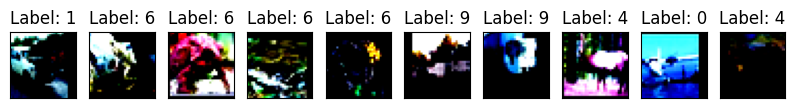

In [4]:
# Get CIFAR10 training and testing datasets from torch
# Define transforms for data normalization and augmentation
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))  # CIFAR-10 mean and std
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Load CIFAR-10 dataset
cifar10_train = torchvision.datasets.CIFAR10(root='../data', train=True, download=True, transform=transform_train)
cifar10_test = torchvision.datasets.CIFAR10(root='../data', train=False, download=True, transform=transform_test)

# Create DataLoaders
batch_size = 128
cifar_dataloader_train = DataLoader(cifar10_train, batch_size=batch_size, shuffle=True, num_workers=2)
cifar_dataloader_test = DataLoader(cifar10_test, batch_size=batch_size, shuffle=False, num_workers=2)

# plot dataset samples
plot_dataset_samples(cifar_dataloader_train, 10)

>**Note:** The images look a bit strange because we used normalisation, where we make images mean=\~0 and std=\~1. Matplotlib (the library we are using for plotting) expects images between 0 and 1 or 0 and 255, so it gets confused with our negative values (this is also the reason for the warning printed in the code output). You could modify your plotting function to "de-normalize" the images prior to plotting -- this is left as an additional exercise if you want.

#Exercise 1:
Recycling code from the previous sessions, create a 1-layer MLP and train it on CIFAR10 for 5 epochs.
- call you model instance ```cifar_simpleMLP```
- Report the final test accuracy.

In [5]:
# nn.Module is the base class for all neural network modules in PyTorch.
# Our SimpleMLP inherits from it.
class SimpleMLP(nn.Module):

    # __init__() method in initializes the layers and attributes of the
    # neural network when an instance is created.
    # Basically, we define all the "building blocks" we need here, and we will
    # combine them in the forward(x) function.
    def __init__(self, n_input_pixels, n_hidden):
        super().__init__()
        self.flatten = nn.Flatten()              # Converts the input image of shape (channels, heigh, width) into a flattened vector of 784 elements.
        self.hidden = nn.Linear(n_input_pixels, n_hidden) # Hidden layer
        self.relu = nn.ReLU()                    # Activation function
        self.output = nn.Linear(n_hidden, 10)    # Output layer
        self.softmax = nn.Softmax(dim=1)         # Activation function

    # forward(x) defines the forward pass of the model, specifying how
    # input x flows through the layers to produce the output.
    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        x = self.softmax(x)
        return x

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.1684225].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.5771239].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..1.9713104].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..1.7001756].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.6171591].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.429065

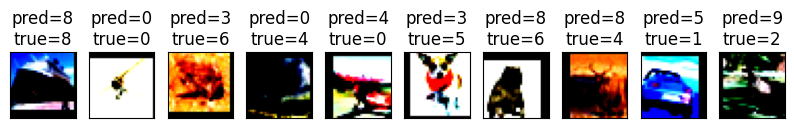

In [6]:
# Create an instance of the model
cifar_simpleMLP = SimpleMLP(n_input_pixels=32*32*3, n_hidden=32)
# Move the model to the desired device
cifar_simpleMLP = cifar_simpleMLP.to(device)
# check initial network predictions on batch
plot_batch_predictions(cifar_simpleMLP, cifar_dataloader_train, 10)

In [7]:
cifar_criterion = nn.CrossEntropyLoss()  # Standardly used for classification
cifar_optimizer = torch.optim.Adam(cifar_simpleMLP.parameters(), lr=0.001)

In [8]:
history = train_and_test(cifar_simpleMLP, cifar_dataloader_train, cifar_dataloader_test, 5, cifar_criterion, cifar_optimizer, device)

Epoch 1/5


Epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]

Batch Loss: 2.1854698657989573

  0%|          | 0/79 [00:00<?, ?it/s]

Test Loss: 2.1040, Accuracy: 35.01%
Epoch 2/5


...

Test Loss: 2.0600, Accuracy: 39.43%
Epoch 5/5


Epoch 5:   0%|          | 0/391 [00:00<?, ?it/s]

Batch Loss: 2.0339527130126953

  0%|          | 0/79 [00:00<?, ?it/s]

Test Loss: 2.0615, Accuracy: 39.44%


#Exercise 2:
###Exercise 2a:
Let's add two new hidden layers to our model and call it MLP_3layers.

Fill in the code below.

In [9]:
# nn.Module is the base class for all neural network modules in PyTorch.
class MLP_3layers(nn.Module):

    # __init__() method in initializes the layers and attributes of the
    # neural network when an instance is created.
    # Basically, we define all the "building blocks" we need here, and we will
    # combine them in the forward(x) function.
    def __init__(self, n_input_pixels, n_hidden):
        super().__init__()
        self.flatten = nn.Flatten()              # Converts the input image of shape (channels, heigh, width) into a flattened vector of 784 elements.
        self.hidden1 = nn.Linear(n_input_pixels, n_hidden) # Hidden layer
        self.hidden2 = nn.Linear(n_hidden, n_hidden) # Hidden layer
        self.hidden3 = nn.Linear(n_hidden, n_hidden) # Hidden layer
        self.relu = nn.ReLU()                    # Activation function
        self.output = nn.Linear(n_hidden, 10)    # Output layer
        self.softmax = nn.Softmax(dim=1)         # Activation function

    # forward(x) defines the forward pass of the model, specifying how
    # input x flows through the layers to produce the output.
    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden1(x)
        x = self.relu(x)
        x = self.hidden2(x)
        x = self.relu(x)
        x = self.hidden3(x)
        x = self.relu(x)
        x = self.output(x)
        x = self.softmax(x)
        return x

###Exercise 2b:
Make an instance of this network and train it on CIFAR10.
- call you model instance ```cifar_MLP_3layers```
- Don't forget to re-define your optimizer! Otherwise it will try to optimize the parameters of our previous ```cifar_SimpleMLP``` instance!
- Report the final test accuracy.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.734221].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.6366696].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.65618].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.1489122].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.0903814].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..

Epoch 1/5


Epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]

Batch Loss: 2.1669571399688727

  0%|          | 0/79 [00:00<?, ?it/s]

...

Test Loss: 2.0583, Accuracy: 39.68%
Epoch 5/5


Epoch 5:   0%|          | 0/391 [00:00<?, ?it/s]

Batch Loss: 2.0655431747436523

  0%|          | 0/79 [00:00<?, ?it/s]

Test Loss: 2.0624, Accuracy: 39.36%


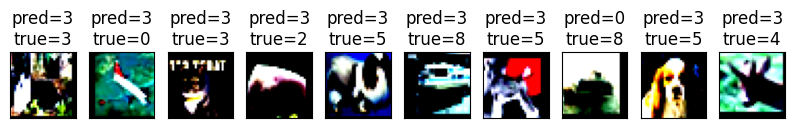

In [10]:
# Create an instance of the model
cifar_MLP_3layers = MLP_3layers(n_input_pixels=32*32*3, n_hidden=32)
# Move the model to the desired device
cifar_MLP_3layers = cifar_MLP_3layers.to(device)
# check initial network predictions on batch
plot_batch_predictions(cifar_MLP_3layers, cifar_dataloader_train, 10)

#Criterion and optimizer
cifar_criterion = nn.CrossEntropyLoss()  # Standardly used for classification
cifar_optimizer = torch.optim.Adam(cifar_MLP_3layers.parameters(), lr=0.001)

# Train/test
history = train_and_test(cifar_MLP_3layers, cifar_dataloader_train, cifar_dataloader_test, 5, cifar_criterion, cifar_optimizer, device)

>*Question:* Is performance better for this network than for our previous, smaller one?

--> In my case, I got about 1% increase in test accuracy, and a very tiny improvement of 0.01 in the test loss. On the other hand, I got a more substantial improvement of 0.1 in *training* loss. What do you think that indicates?

----> It's a sign that adding the layers led to more overfitting: better training loss but not much better testing loss.

###Bonus:

Here I am showing you some code for a CustomMLP where you can input the number of layers and the number of units in each layer when you create an instance of the network.

You do not need to go over it if you don't want to. But I am including it here so you can see how we could code a slighly more flexible network.

In [11]:
# Model class
class CustomMLP(nn.Module):
    def __init__(self, input_size, n_hidden_list, output_size, activation_fn):
        super().__init__()
        self.flatten = nn.Flatten()
        self.activation = activation_fn

        self.hidden_layers = nn.ModuleDict()
        # Create hidden layers with names
        for i, n_hidden in enumerate(n_hidden_list):
            self.hidden_layers[f'fc{i+1}'] = nn.Linear(input_size, n_hidden)
            input_size = n_hidden

        self.output = nn.Linear(input_size, output_size)

    def forward(self, x):
        x = self.flatten(x)
        for name, layer in self.hidden_layers.items():
            x = layer(x)
            x = self.activation(x)
        x = self.output(x)
        return x

Then, we could create an instance of this model as follows:

In [12]:
n_hidden_list = [64, 64, 32]
activation_type = nn.ReLU()

cifar_customMLP = CustomMLP(32*32*3, n_hidden_list, 10, activation_type)
cifar_customMLP = cifar_customMLP.to(device)

>*Bonus question:* Can you draw a schematic of what this network instance we just created looks like?

#Exercise 3:

One reason why our previous 3-layer MLP model did not improve much compared to the 1-layer MLP may be that it does not have good *inductive biases* (cf. lecture from this week).

**Convolutional Neural Networks (CNNs)** have an architecture inspired by the visual system, which gives it good inductive biases for visual processing (again, cf. this week's lecture).

Next we will create a 3-layer CNN, and see how it does on CIFAR10.

In [13]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # First convolutional layer:
        # Input: 3 channels (RGB), Output: 32 feature maps
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)

        # Second convolutional layer:
        # Input: 32 feature maps, Output: 64 feature maps
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)

        # Third convolutional layer:
        # Input: 64 feature maps, Output: 128 feature maps
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)

        # Max pooling layer:
        # Reduces spatial size (height and width) by a factor of 2
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Activation function:
        # Applies ReLU nonlinearity after each convolution
        self.relu = nn.ReLU()

        # Adaptive average pooling:
        # Pools across the entire spatial extent of the layer.
        # This reduces each feature map to size 1x1, regardless of input size
        # for example, if our previous layer has [128 channels, 4 rows, 4 cols],
        # the output of this operation will be of size [128, 1, 1]
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Fully connected (dense) layer:
        # Input size is 128*1*1 because adaptive pooling outputs (batch, 128, 1, 1)
        self.fc1 = nn.Linear(128 * 1 * 1, 256)

        # Final output layer:
        # Maps to 10 output classes (e.g., for CIFAR-10)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        # Apply first convolution + ReLU + pooling
        x = self.relu(self.conv1(x))
        x = self.pool(x)

        # Apply second convolution + ReLU + pooling
        x = self.relu(self.conv2(x))
        x = self.pool(x)

        # Apply third convolution + ReLU
        x = self.relu(self.conv3(x))

        # Apply adaptive pooling to get a fixed spatial size of 1x1
        x = self.adaptive_pool(x)

        # Flatten the feature maps into a vector:
        # x.size(0) is the batch size, the rest is flattened
        x = x.view(x.size(0), -1)

        # Pass through fully connected layer + ReLU
        x = self.relu(self.fc1(x))

        # Final classification layer
        x = self.fc2(x)

        return x


Now, make an instance of our convolutional network and train it on cifar 10.
- call you model instance ```cifar_SimpleCNN```
- Don't forget to re-define your optimizer!
- Report the final test accuracy.

Epoch 1/5


Epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]

Batch Loss: 1.5535166263580322

  0%|          | 0/79 [00:00<?, ?it/s]

Test Loss: 1.4513, Accuracy: 46.55%
Epoch 2/5


...

Epoch 5:   0%|          | 0/391 [00:00<?, ?it/s]

Batch Loss: 0.9938448071479797

  0%|          | 0/79 [00:00<?, ?it/s]

Test Loss: 0.9866, Accuracy: 64.69%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.514088].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.3245049].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.4591227].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.1457746].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657

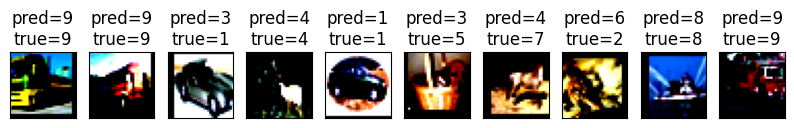

In [14]:
# Create an instance of the model
cifar_simpleCNN = SimpleCNN()
# Move the model to the desired device
cifar_simpleCNN = cifar_simpleCNN.to(device)

#Criterion and optimizer
cifar_criterion = nn.CrossEntropyLoss()  # Standardly used for classification
cifar_optimizer = torch.optim.Adam(cifar_simpleCNN.parameters(), lr=0.001)

# Train/test
history = train_and_test(cifar_simpleCNN, cifar_dataloader_train, cifar_dataloader_test, 5, cifar_criterion, cifar_optimizer, device)

# check final network predictions on batch
plot_batch_predictions(cifar_simpleCNN, cifar_dataloader_train, 10)

The accuracy should have imoproved quite dramatically compared to our MLPs! Feel free to play around with the architecture to imrpve the result even further if you want!

#Bonus exercise:

The following code shows you how to create a small recurrent convolutional network with top-down connections between layers.

This is starting to get a bit tricky, feel free to challenge yourself to understand it (**<font color='red'>not required for this class</font>**).

>**Note 1:** We'll use MLP layers rather than CNN layers for simplicity. We can of course create recurrent CNNs, but that's slightly more complicated and beyond the scope of this course. In general, a *lot* more could be said about recurrent nets, but we sadly don't have time.

>**Note 2:** This might be a little hard to understand. True recurrent networks like this are a bit complex. Good luck!

In [15]:
class RecurrentMLP(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, hidden3, output_size, num_timesteps=4):
        super(RecurrentMLP, self).__init__()

        self.num_timesteps = num_timesteps

        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()

        # Bottom-up weights (bu stands for bottum-up connection)
        self.bu1 = nn.Linear(input_size, hidden1)
        self.bu2 = nn.Linear(hidden1, hidden2)
        self.bu3 = nn.Linear(hidden2, hidden3)

        # Top-down feedback weights (td stands for top-down connection)
        self.td_21 = nn.Linear(hidden2, hidden1)  # from h2 to h1
        self.td_32 = nn.Linear(hidden3, hidden2)  # from h3 to h2

        # Output layer
        self.readout = nn.Linear(hidden3, output_size)

    def forward(self, x):

        # flatten input
        x_flat = self.flatten(x)

        # Input is always the same so we only compute it once
        h1_bu = self.bu1(x_flat)

        for t in range(self.num_timesteps):
            # Bottom-up + top-down for each layer
            if t > 0:
                h1_bu_plus_td = h1_bu + self.td_21(h2)
                h1 = self.relu(h1_bu_plus_td)
            else:
                h1 = self.relu(h1_bu)

            h2_bu = self.bu2(h1)
            if t > 0:
                h2_bu_plus_td = h2_bu + self.td_32(h3)
                h2 = self.relu(h2_bu_plus_td)
            else:
                h2 = self.relu(h2_bu)

            h3 = self.relu(self.bu3(h2))  # no top-down to h3

        # Final output from last h3
        out = self.readout(h3)
        return out


Epoch 1/5


Epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]

Batch Loss: 1.8776404857635498

  0%|          | 0/79 [00:00<?, ?it/s]

Test Loss: 1.7370, Accuracy: 37.60%
Epoch 2/5


...

Epoch 5:   0%|          | 0/391 [00:00<?, ?it/s]

Batch Loss: 1.6522190570831299

  0%|          | 0/79 [00:00<?, ?it/s]

Test Loss: 1.5662, Accuracy: 43.59%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..1.6223819].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..0.82760036].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.402546].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.2854843].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.429065

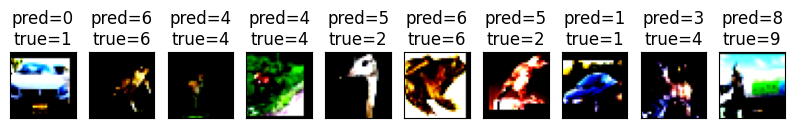

In [16]:
# Create an instance of the model
cifar_recMLP = RecurrentMLP(input_size=3*32*32,
                            hidden1=32,
                            hidden2=32,
                            hidden3=32,
                            output_size=10,
                            num_timesteps=4)
# Move the model to the desired device
cifar_recMLP = cifar_recMLP.to(device)

#Criterion and optimizer
cifar_criterion = nn.CrossEntropyLoss()  # Standardly used for classification
cifar_optimizer = torch.optim.Adam(cifar_recMLP.parameters(), lr=0.001)

# Train/test
history = train_and_test(cifar_recMLP, cifar_dataloader_train, cifar_dataloader_test, 5, cifar_criterion, cifar_optimizer, device)

# check final network predictions on batch
plot_batch_predictions(cifar_recMLP, cifar_dataloader_train, 10)

I get slightly better performance than for the non-recurrent MLP, but not as good as the CNN.

If you want to challenge yourself further, try to add more recurrent layers, or to add lateral connections to a layer!